In [193]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df_train=pd.read_csv('../../data/F1/train.csv')
df_test=pd.read_csv('../../data/F1/test.csv')
print(df_train.shape)
df_train.head()

(439140, 16)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [194]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [195]:
df_train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


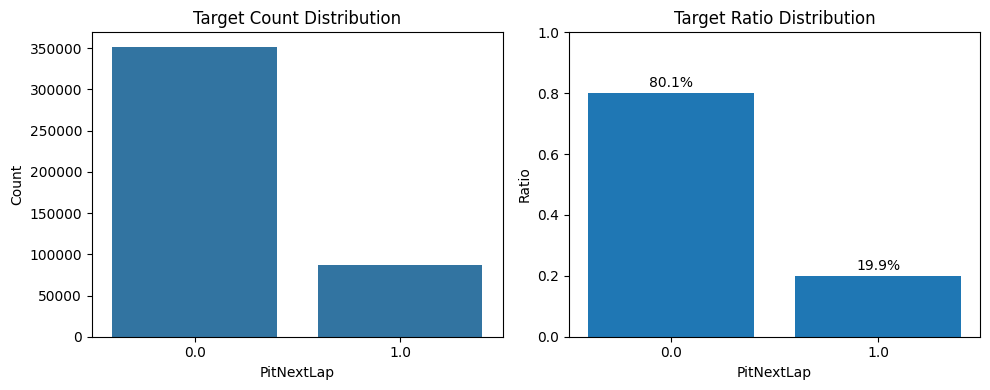

,count,ratio
PitNextLap,,
0.0,351759,0.801018
1.0,87381,0.198982


In [196]:
target_counts = df_train['PitNextLap'].value_counts().sort_index()
target_ratio = df_train['PitNextLap'].value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=df_train, x='PitNextLap', ax=axes[0])
axes[0].set_title('Target Count Distribution')
axes[0].set_xlabel('PitNextLap')
axes[0].set_ylabel('Count')

axes[1].bar(target_ratio.index.astype(str), target_ratio.values)
axes[1].set_title('Target Ratio Distribution')
axes[1].set_xlabel('PitNextLap')
axes[1].set_ylabel('Ratio')
axes[1].set_ylim(0, 1)

for i, value in enumerate(target_ratio.values):
    axes[1].text(i, value + 0.02, f'{value:.1%}', ha='center')

plt.tight_layout()
plt.show()

pd.DataFrame({'count': target_counts, 'ratio': target_ratio})

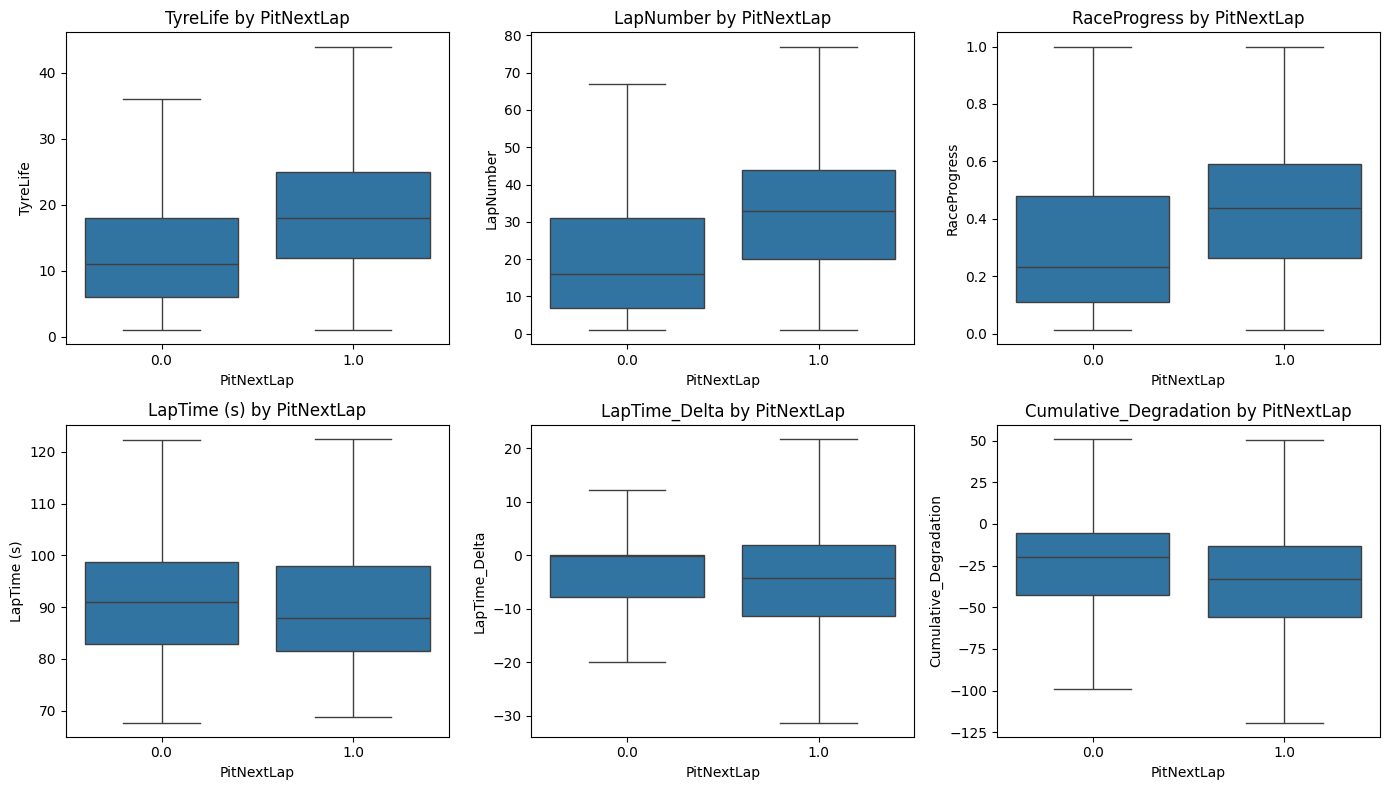

In [197]:
target_box_features = [
    'TyreLife',
    'LapNumber',
    'RaceProgress',
    'LapTime (s)',
    'LapTime_Delta',
    'Cumulative_Degradation'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, target_box_features):
    sns.boxplot(data=df_train, x='PitNextLap', y=col, ax=ax, showfliers=False)
    ax.set_title(f'{col} by PitNextLap')
    ax.set_xlabel('PitNextLap')

plt.tight_layout()
plt.show()

## Data cleaning

In [198]:
drop_cols=['id']
df_train_clean=df_train.drop(drop_cols,axis=1)
df_test_clean=df_test.drop(drop_cols,axis=1)

In [199]:
df_train_clean.sort_values('LapTime (s)',ascending=False).head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
419357,D076,MEDIUM,Monaco Grand Prix,2025,0,1,1,1.0,9,2507.607,2412.643,-1.018,0.012987,5.0,0.0
245155,MAL,MEDIUM,Monaco Grand Prix,2024,0,1,1,1.0,8,2502.809,24.926,2385.714,0.012987,1.0,0.0
248029,BUE,HARD,Monaco Grand Prix,2024,0,1,1,1.0,17,2502.648,19.937,2390.333,0.013158,-13.0,0.0
358055,D114,MEDIUM,Las Vegas Grand Prix,2025,0,1,1,1.0,2,2497.820,24.978,2406.800,0.013158,7.0,0.0
237295,FIS,HARD,Monaco Grand Prix,2024,1,1,1,2.0,13,2497.678,2406.326,2383.678,0.013158,-7.0,0.0


In [200]:
df_train_clean[df_train_clean['LapTime (s)']>500]

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
67979,D047,MEDIUM,Austrian Grand Prix,2023,0,2,1,2.0,1,2473.241,23.820,2377.540,0.028169,0.0,0.0
73750,D150,MEDIUM,Monaco Grand Prix,2025,0,1,1,1.0,3,2473.273,24.272,11.978,0.012821,-2.0,0.0
175487,BRA,MEDIUM,Belgian Grand Prix,2024,0,1,1,1.0,2,2387.902,2423.932,7.824,0.012821,3.0,0.0
183041,FON,HARD,Monaco Grand Prix,2024,1,1,1,1.0,4,2497.268,24.080,2370.062,0.012821,-2.0,0.0
237295,FIS,HARD,Monaco Grand Prix,2024,1,1,1,2.0,13,2497.678,2406.326,2383.678,0.013158,-7.0,0.0
245155,MAL,MEDIUM,Monaco Grand Prix,2024,0,1,1,1.0,8,2502.809,24.926,2385.714,0.012987,1.0,0.0
248029,BUE,HARD,Monaco Grand Prix,2024,0,1,1,1.0,17,2502.648,19.937,2390.333,0.013158,-13.0,0.0
255988,PIQ,HARD,Monaco Grand Prix,2024,0,1,1,1.0,11,2488.609,23.734,2381.300,0.013158,-4.0,0.0
256648,HAR,HARD,Monaco Grand Prix,2024,0,1,1,1.0,7,2488.809,24.926,2383.678,0.012821,-5.0,0.0
262674,D019,MEDIUM,Monaco Grand Prix,2025,0,1,1,2.0,4,2473.461,15.976,24.733,0.012821,0.0,0.0


In [201]:
# Removing outliers
abn_col=['LapTime (s)','LapTime_Delta','Cumulative_Degradation']
upper_bound=df_train_clean[abn_col].quantile(0.999)
lower_bound=df_train_clean[abn_col].quantile(0.001)
lower_bound[0]=df_train_clean['LapTime (s)'].min()
mask = (
    (df_train_clean[abn_col] >= lower_bound) &
    (df_train_clean[abn_col] <= upper_bound)
).all(axis=1)

df_train_clean_2=df_train_clean[mask]

df_test_clean_2=df_test_clean.copy()
df_test_clean_2[abn_col] = df_test_clean_2[abn_col].clip(lower=lower_bound,upper=upper_bound,axis=1)

In [202]:
df_train_clean_2.describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,437127.00000,437127.000000,437127.000000,437127.000000,437127.000000,437127.000000,437127.000000,437127.000000,437127.000000,437127.000000,437127.000000,437127.000000
mean,2023.52175,0.135901,23.138232,1.790567,14.175300,9.624629,90.750369,-3.167244,-25.773846,0.338202,0.102430,0.199068
std,1.02313,0.342684,16.955130,0.951008,9.793808,5.278872,11.215230,12.317490,51.780051,0.253286,4.000948,0.399300
min,2022.00000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-63.239000,-262.570000,0.012821,-18.000000,0.000000
25%,2023.00000,0.000000,9.000000,1.000000,6.000000,5.000000,82.622000,-8.877000,-46.506000,0.129870,-1.000000,0.000000
50%,2024.00000,0.000000,19.000000,2.000000,12.000000,10.000000,90.467000,-0.296000,-21.009000,0.269231,0.000000,0.000000
75%,2024.00000,0.000000,36.000000,2.000000,20.000000,14.000000,98.418000,0.113000,-6.277000,0.513158,2.000000,0.000000
max,2025.00000,1.000000,78.000000,8.000000,77.000000,20.000000,146.674000,49.360000,147.346000,1.000000,18.000000,1.000000


## Prepocessing

In [203]:
n_train=df_train_clean_2.shape[0]
all_features=pd.concat([df_train_clean_2.drop(columns='PitNextLap'),df_test_clean_2],axis=0)
all_features.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0


In [204]:
#one-hot
df_onehot=pd.get_dummies(all_features,dtype=bool)
df_onehot.head()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,...,Race_Mexico City Grand Prix,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Testing,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix
0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,...,False,False,False,False,False,False,False,False,False,False
1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,...,False,False,False,False,False,False,False,False,False,False
2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,...,False,False,False,False,False,False,False,False,False,False
3,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,...,False,False,False,True,False,False,False,False,False,False
4,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,...,False,False,False,False,False,False,False,False,False,False


In [205]:
numeric_features=df_onehot.select_dtypes(exclude=bool).columns
cat_features=df_onehot.select_dtypes(include=bool).columns
X_train_onehot=df_onehot.iloc[:n_train,:]
X_test_onehot=df_onehot.iloc[n_train:,:]
X_train_onehot.head()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,...,Race_Mexico City Grand Prix,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Testing,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix
0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,...,False,False,False,False,False,False,False,False,False,False
1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,...,False,False,False,False,False,False,False,False,False,False
2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,...,False,False,False,False,False,False,False,False,False,False
3,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,...,False,False,False,True,False,False,False,False,False,False
4,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,...,False,False,False,False,False,False,False,False,False,False


In [206]:
stnd=StandardScaler().set_output(transform="pandas")
X_train_scaled=stnd.fit_transform(X_train_onehot[numeric_features])
X_train=pd.concat([X_train_scaled,X_train_onehot[cat_features].astype(float)],axis=1)

X_test_scaled=stnd.transform(X_test_onehot[numeric_features])
X_test=pd.concat([X_test_scaled,X_test_onehot[cat_features].astype(float)],axis=1)

y_train=df_train_clean_2['PitNextLap']


In [207]:
X_test.describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,...,Race_Mexico City Grand Prix,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Testing,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix
count,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,...,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000
mean,0.006539,0.001057,-0.005193,-0.006655,-0.001498,-0.003806,0.009098,0.001803,-0.003498,-0.005951,...,0.054718,0.043324,0.048750,0.051269,0.031510,0.041740,0.042968,0.046310,0.027173,0.040821
std,1.002197,1.001125,1.002783,0.997680,1.006022,0.998973,1.016936,1.018663,1.010432,1.000436,...,0.227429,0.203585,0.215345,0.220546,0.174691,0.199995,0.202785,0.210157,0.162588,0.197875
min,-1.487350,-0.396579,-1.305697,-0.831295,-1.345270,-1.633803,-2.055811,-4.876954,-4.574085,-1.284644,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.509955,-0.396579,-0.833863,-0.831295,-0.834743,-0.876065,-0.723693,-0.463306,-0.406338,-0.829092,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.467439,-0.396579,-0.244070,0.220223,-0.222110,0.071108,-0.023662,0.233996,0.091673,-0.272307,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.467439,-0.396579,0.758578,0.220223,0.594734,0.828847,0.689655,0.267039,0.378251,0.689414,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.444833,2.521566,3.176728,6.529327,6.414744,1.965455,4.986406,4.264659,3.343373,2.612855,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Dataset Visualization

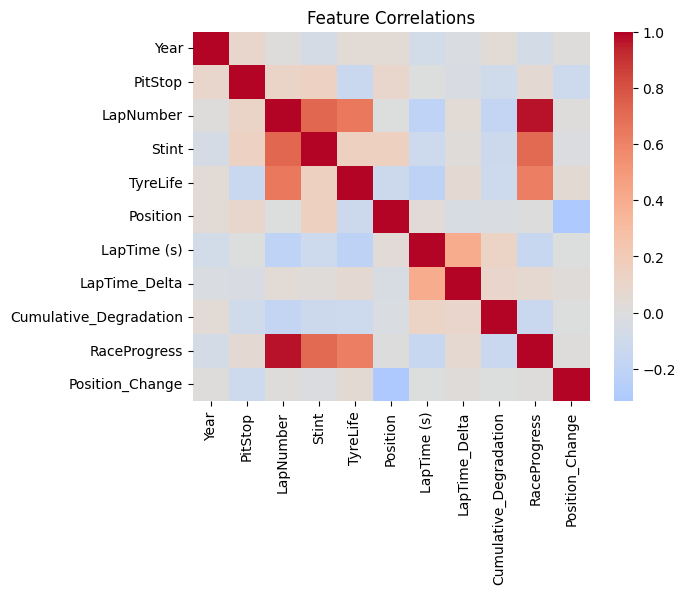

In [208]:
sns.heatmap(X_train[numeric_features].corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlations')
plt.show()

From the correlation heatmap, `LapNumber` and `RaceProgress` are strongly correlated, which is expected because both describe how far the race has progressed. `LapNumber`, `TyreLife`, `Stint`, and `RaceProgress` also show positive relationships, suggesting that tire age and stint number generally increase as the race moves forward.

`LapTime_Delta` and `Cumulative_Degradation` have a noticeable positive correlation, so changes in lap time are related to accumulated tire or performance degradation. Most other features have weak correlations, which means the pit-stop decision is likely influenced by a combination of race progress, tire life, stint information, and lap-time behavior rather than a single variable.

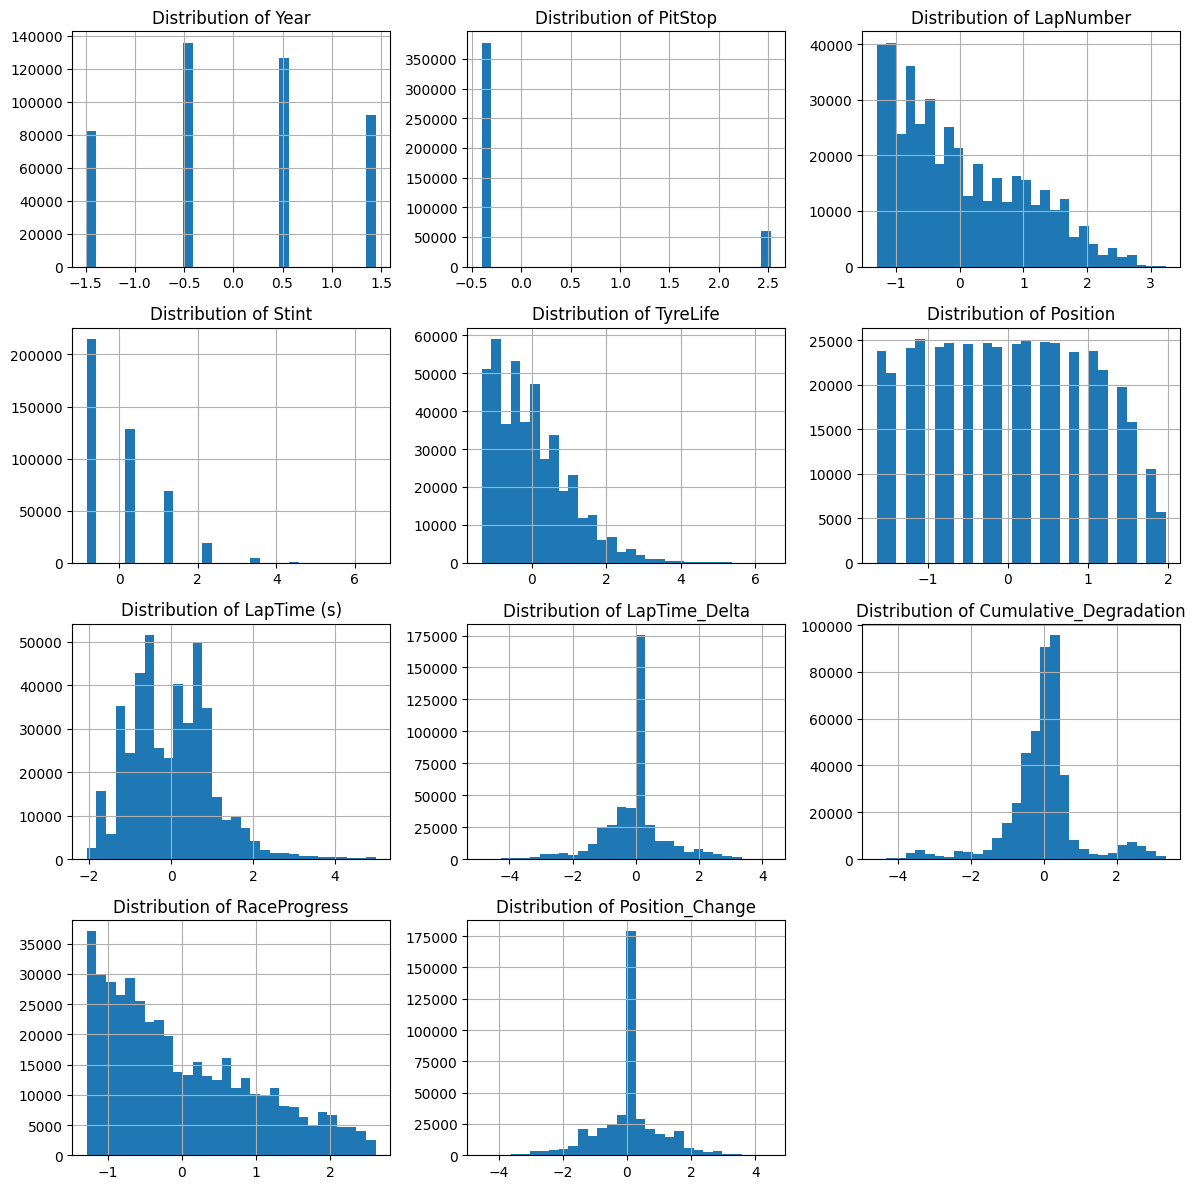

In [209]:
n_cols = 3
n_features = len(X_train[numeric_features].columns)
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, X_train[numeric_features].columns):
    X_train[col].hist(bins=30, ax=ax)
    ax.set_title(f'Distribution of {col}')

for ax in axes[n_features:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

The distribution plots show that most samples come from early or middle parts of races. `Stint` is concentrated around the first and second stints, and `TyreLife` is right-skewed, meaning most tires are relatively young while only a small number of samples have very old tires. `Position` is fairly spread across the grid, while `Position_Change` is centered near zero, showing that most laps do not involve large position changes.

`LapTime (s)`, `LapTime_Delta`, and `Cumulative_Degradation` have strong long tails and extreme values. These may correspond to abnormal laps, pit laps, safety-car periods, testing laps, or noisy records, so they should be checked before modeling. Overall, the dataset describes F1 lap-level race states, and the most useful signals for predicting `PitNextLap` appear to be race progress, tire life, stint context, and lap-time degradation.